<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Assignments/Assignment_Quiz/TimeSeries_Assignment_Quiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement:**

1. Time-series datasets are highly popular and provide a wide range of countless applications such as stock market investigation, financial and sales forecasting, and budget analysis, to name a few.
2. They are also beneficial for studying natural phenomena like atmospheric pressure, temperature, wind speeds, earthquakes, and medical predictions for treatment. An observed time series can be categorized into three main components: the trend i.e the long cycle, the seasonal systematic or calendar associated movements, and the irregular unsystematic or short-term instabilities.

**Data Description**

This data set includes 5 years of Temperature Data for a Specific City having 1826 records .

| Feature Name | Description                                              |
|--------------|---------------------------------------------------------|
| MIN Temp     | Minimum Temperature Recorded for the Day in celsius     |
| Max Temp     | Maximum Temperature Recorded for the Day in celsius     |
| Avg Temp     | Average Temperature Recorded for the Day in celsius     |
| Sunrise      | Time in the morning when the sun appears                |
| Sunset       | Time in the evening when the daylight faded             |


There is another dataset in the download resources zip. It is stock market data. Columns - Open, High, Low, Close

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1) How many Days Average temperature exceeds 50 celsius?
- 278
- 175
- 420
- 331

In [ ]:
weather = pd.read_csv('/content/MaunaLoaDailyTemps.csv')

In [ ]:
weather

,DATE,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
0,1/1/2014,33.0,46.0,40.0,657,1756
1,1/2/2014,35.0,50.0,43.0,657,1756
2,1/3/2014,36.0,45.0,41.0,657,1757
3,1/4/2014,32.0,41.0,37.0,658,1757
4,1/5/2014,24.0,38.0,31.0,658,1758
...,...,...,...,...,...,...
1820,12/26/2018,35.0,45.0,40.0,654,1752
1821,12/27/2018,33.0,44.0,39.0,655,1752
1822,12/28/2018,33.0,47.0,40.0,655,1753
1823,12/29/2018,36.0,47.0,42.0,655,1753


In [ ]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DATE     1825 non-null   object 
 1   MinTemp  1821 non-null   float64
 2   MaxTemp  1821 non-null   float64
 3   AvgTemp  1821 non-null   float64
 4   Sunrise  1825 non-null   int64  
 5   Sunset   1825 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 85.7+ KB


In [ ]:
weather.isnull().sum()

,0
DATE,0
MinTemp,4
MaxTemp,4
AvgTemp,4
Sunrise,0
Sunset,0


In [ ]:
(weather['AvgTemp']>50).sum()

331

In [ ]:
len(weather[weather['AvgTemp']>50])

331

1. Answer - 331

2) Which year will be termed as the hottest year?
- 2016
- 2017
- 2018
- 2014

In [ ]:
type(weather['DATE'][0])

str

In [ ]:
weather_original = weather.copy()
# this will not be touched

In [ ]:
# convert DATE column to datetime
weather['DATE'] = pd.to_datetime(weather['DATE'])

In [ ]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   DATE     1825 non-null   datetime64[ns]
 1   MinTemp  1821 non-null   float64       
 2   MaxTemp  1821 non-null   float64       
 3   AvgTemp  1821 non-null   float64       
 4   Sunrise  1825 non-null   int64         
 5   Sunset   1825 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 85.7 KB


In [ ]:
weather.groupby(weather['DATE'].dt.year)['AvgTemp'].mean()


,AvgTemp
DATE,
2014,46.296703
2015,47.145205
2016,47.687671
2017,46.642857
2018,46.316804


In [ ]:
weather.groupby(weather['DATE'].dt.year)['AvgTemp'].mean().idxmax()

2016

In [ ]:
weather.set_index('DATE', inplace=True) #default drop=True to drop the column

In [ ]:
weather

,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
DATE,,,,,
2014-01-01,33.0,46.0,40.0,657,1756
2014-01-02,35.0,50.0,43.0,657,1756
2014-01-03,36.0,45.0,41.0,657,1757
2014-01-04,32.0,41.0,37.0,658,1757
2014-01-05,24.0,38.0,31.0,658,1758
...,...,...,...,...,...
2018-12-26,35.0,45.0,40.0,654,1752
2018-12-27,33.0,44.0,39.0,655,1752
2018-12-28,33.0,47.0,40.0,655,1753


In [ ]:
yearly_avg = weather['AvgTemp'].resample('Y').mean()

/tmp/ipython-input-156591487.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_avg = weather['AvgTemp'].resample('Y').mean()


In [ ]:
yearly_avg = weather['AvgTemp'].resample('YE').mean()

In [ ]:
yearly_avg

,AvgTemp
DATE,
2014-12-31,46.296703
2015-12-31,47.145205
2016-12-31,47.687671
2017-12-31,46.642857
2018-12-31,46.316804


In [ ]:
yearly_avg.idxmax().year

2016

---

##### 🧩 Why Missing Data Happens in Resampling

When you **resample** your data (say from *daily → monthly* or *hourly → daily*), pandas might create **new time periods** that didn’t exist in the original dataset.

For example:

* If one day’s data is missing in your original dataset.
* Or if your data didn’t have any record on a weekend/holiday.
* Then, after `resample()`, those missing days/months will appear as `NaN`.

That’s when you use **`.ffill()`, `.bfill()`, or `.interpolate()`**.

---

##### ⚙️ Options to Handle Missing Values

###### 1️⃣ `.ffill()` → **Forward Fill**

It fills missing values using the **last known value** (previous observation).

```python
df_resampled = df.resample('D').mean().ffill()
```

👉 Meaning:
If you’re missing data on Jan 5, pandas uses Jan 4’s value.

**Use it when:**

* The last known observation is still relevant (e.g., temperature, stock prices, etc.)
* The value doesn’t change drastically between time steps.

---

###### 2️⃣ `.bfill()` → **Backward Fill**

It fills missing values using the **next known value**.

```python
df_resampled = df.resample('D').mean().bfill()
```

👉 Meaning:
If Jan 5 is missing, pandas uses Jan 6’s value.

**Use it when:**

* You want to assume the next known value applies backward.
* Common in some reporting systems (e.g., when data appears delayed).

---

###### 3️⃣ `.interpolate()` → **Linear (or polynomial/spline) interpolation**

It fills missing values by **estimating intermediate values** based on trends.

```python
df_resampled = df.resample('D').mean().interpolate()
```

👉 Meaning:
If Jan 4 = 25°C and Jan 6 = 27°C, then Jan 5 ≈ 26°C (linearly estimated).

**Use it when:**

* Your data is **continuous** (like temperature, humidity, etc.)
* You want a smoother and more natural transition than ffill/bfill.

You can even choose a method:

```python
df_resampled = df.resample('D').mean().interpolate(method='time')
```

---

##### 🧠 Example Comparison

Let’s say you resampled daily temperature but one day was missing:

| Date  | Temp |
| ----- | ---- |
| Jan 1 | 25   |
| Jan 2 | NaN  |
| Jan 3 | 27   |

| Method           | Jan 2 Value | Explanation                  |
| ---------------- | ----------- | ---------------------------- |
| `.ffill()`       | 25          | Uses Jan 1 value             |
| `.bfill()`       | 27          | Uses Jan 3 value             |
| `.interpolate()` | 26          | Calculates between 25 and 27 |

---

✅ **Summary Table**

| Method           | Use Case                     | Ideal For                                    |
| ---------------- | ---------------------------- | -------------------------------------------- |
| `.ffill()`       | carry previous value forward | stock prices, sensor data with steady states |
| `.bfill()`       | fill using next value        | missing start-of-series values               |
| `.interpolate()` | estimate in-between values   | continuous numeric data like temperature     |

---


In [ ]:
yearly_avg.idxmax().year

2016

2. Answer - 2016

3) How you will be handling missing values in this dataset:
- Fill up the null values with None.
- Fill up the null values with standard deviation.
- Fill up the null values with the median.
- Fill up the null values with the mean.

We have missing values in  MinTemp , MaxTemp   and  AvgTemp

---

**Option:** Fill up the null values with **None**
**Explanation:** `None` is not numeric; converting column to object dtype.
**Suitable?** ❌ Wrong

---

**Option:** Fill up the null values with **Standard Deviation**
**Explanation:** Std. deviation shows spread, not an actual value to fill.
**Suitable?** ❌ Wrong

---

**Option:** Fill up the null values with **Median**
**Explanation:** Robust to outliers; good for skewed data.
**Suitable?** ✅ Acceptable

---

**Option:** Fill up the null values with **Mean**
**Explanation:** Represents average temperature; best for continuous numeric data.
**Suitable?** ✅ **Best Answer**

---


In [ ]:
weather['MinTemp'].fillna(weather['MinTemp'].mean(), inplace=True)
weather['MaxTemp'].fillna(weather['MaxTemp'].mean(), inplace=True)
weather['AvgTemp'].fillna(weather['AvgTemp'].mean(), inplace=True)

/tmp/ipython-input-2213737793.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  weather['MinTemp'].fillna(weather['MinTemp'].mean(), inplace=True)
/tmp/ipython-input-2213737793.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [ ]:
weather.isnull().sum()

,0
MinTemp,0
MaxTemp,0
AvgTemp,0
Sunrise,0
Sunset,0


3. Answer - Fill up the null values with the mean.

4) Which columns are not having any kind of relationship with the MaxTemp column?
- Sunrise
- Sunset
- Both 1 And 3
- MinTemp

In [ ]:
weather.corr()

,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
MinTemp,1.000000,0.756071,0.917456,-0.426545,0.300292
MaxTemp,0.756071,1.000000,0.951039,-0.374685,0.275693
AvgTemp,0.917456,0.951039,1.000000,-0.422555,0.304508
Sunrise,-0.426545,-0.374685,-0.422555,1.000000,-0.739530
Sunset,0.300292,0.275693,0.304508,-0.739530,1.000000


In [ ]:
weather['Sunrise']

,Sunrise
DATE,
2014-01-01,657
2014-01-02,657
2014-01-03,657
2014-01-04,658
2014-01-05,658
...,...
2018-12-26,654
2018-12-27,655
2018-12-28,655


.corr()`** (correlation) in pandas to check which columns **do or do not have a relationship** with `MaxTemp`.

Let’s go step-by-step:

---

##### Interpret correlation values

| Correlation value | Meaning                      |
| ----------------- | ---------------------------- |
| **Close to +1**   | Strong positive relationship |
| **Close to -1**   | Strong negative relationship |
| **Close to 0**    | No significant relationship  |

---

#####  Analyze your data

Typically, in temperature datasets:

* `MinTemp` → **strongly correlated** with `MaxTemp` (both rise/fall together).
* `AvgTemp` → also **strongly correlated** with `MaxTemp`.
* `Sunrise` and `Sunset` → **time values**, not directly related to temperature (weak or no correlation).

---

##### Correct quiz answer

| Option  | Relation with MaxTemp |
| ------- | --------------------- |
| Sunrise | ❌ No strong relation  |
| Sunset  | ❌ No strong relation  |
| MinTemp | ✅ Strong relation     |

Hence:

✅ **Answer: Both 1 and 3 (Sunrise and Sunset)**

---

##### 💡 Bonus tip:

If `Sunrise` and `Sunset` are stored as integers like `600`, `1830` (HHMM format), you can still include them in `.corr()`, but correlation will be misleading — they’re *time of day*, not continuous numerical features.

So it’s conceptually correct to say they **don’t have a relationship** with `MaxTemp`.


In [ ]:
weather.corr(numeric_only=True)  #include only numeric features in corr

,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
MinTemp,1.000000,0.756071,0.917456,-0.426545,0.300292
MaxTemp,0.756071,1.000000,0.951039,-0.374685,0.275693
AvgTemp,0.917456,0.951039,1.000000,-0.422555,0.304508
Sunrise,-0.426545,-0.374685,-0.422555,1.000000,-0.739530
Sunset,0.300292,0.275693,0.304508,-0.739530,1.000000


In [ ]:
weather.corr(numeric_only=True)['MaxTemp']

,MaxTemp
MinTemp,0.756071
MaxTemp,1.000000
AvgTemp,0.951039
Sunrise,-0.374685
Sunset,0.275693


In [ ]:
weather.corr(numeric_only=True)['MaxTemp'].abs() # now we can check if they are close to 1

,MaxTemp
MinTemp,0.756071
MaxTemp,1.000000
AvgTemp,0.951039
Sunrise,0.374685
Sunset,0.275693


In [ ]:
weather.corr(numeric_only=True)['MaxTemp'].abs().sort_values()

,MaxTemp
Sunset,0.275693
Sunrise,0.374685
MinTemp,0.756071
AvgTemp,0.951039
MaxTemp,1.000000


In [ ]:
weather.corr(numeric_only=True)['MaxTemp'].abs() < 0.5

,MaxTemp
MinTemp,False
MaxTemp,False
AvgTemp,False
Sunrise,True
Sunset,True


Both Sunrise and Sunset has less than 0.5 corr (either +ve or -ve) with MaxTemp

4. Answer - Both 1 And 3

5) Which of the following Order is the best order for ARIMA Model on top of the Above Dataset for the target variable - AvgTemp
- ARIMA(3,0,2)
- ARIMA(1,0,5)
- ARIMA(0,0,5)
- ARIMA(2,0,5)

**Quick workflow (summary)**

1. Check stationarity → determine d (ADF test, plot)

2. Use ACF / PACF to get candidate p and q (visual hints)

3. Fit candidate ARIMA(p,d,q) models → compare AIC / BIC

4. Check residual diagnostics (autocorrelation, mean≈0, normal-ish)

4. Compare forecast performance on a holdout set (RMSE / MAE)

5. Pick model that balances low AIC/BIC, good residuals, and low forecast error

---

###### **How to interpret the outputs**

* **ADF p-value**

  * `p < 0.05` → series is (likely) stationary → `d = 0` OK.
  * `p >= 0.05` → nonstationary → try `d = 1` (difference once) and test again.

* **ACF / PACF**

  * ACF slow decay → suggests differencing (d>0).
  * PACF with a sharp cutoff at lag p → AR(p).
  * ACF with a sharp cutoff at lag q → MA(q).
  * Seasonal spikes at lags like 12, 24, 365 → seasonality (consider SARIMA).

* **AIC / BIC**

  * Lower is better (tradeoff: BIC penalizes complexity more). Use them to choose among fitted candidates.

* **RMSE (on holdout)**

  * Low RMSE → better out-of-sample forecasting. This is often the final deciding factor.

* **Residual diagnostics**

  * Residuals should look like white noise (plot `resid.plot()` and `plot_acf(resid)`), and Ljung-Box test should not reject whiteness. If residuals are autocorrelated you may need to increase orders or use seasonal terms.

---

###### **Notes & tips specific to temperature data**

* Temperature usually has **seasonality** (yearly), so plain ARIMA with d=0 might underperform — consider **SARIMA** with seasonal period `s=365` or `s=12` if monthly aggregated.
* The dataset you showed had `d=0` candidates; check stationarity carefully — many daily temp series are seasonal-trend and need differencing or seasonal terms.
* If models fail to converge or coefficients are unstable, reduce p/q or try regularization (or `auto_arima`).

---

###### **Automated alternative**

You can use `pmdarima.auto_arima()` to search over ranges of p,d,q and seasonal orders; it optimizes AIC/BIC and returns a recommended order quickly:

```python
import pmdarima as pm
auto = pm.auto_arima(series.dropna(), seasonal=True, m=365, stepwise=True,
                     max_p=5, max_q=5, max_P=2, max_Q=2, trace=True)
print(auto.summary())
```

---


In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
def check_stationarity(timeseries): # assuming timeseries has no null
  result = adfuller(timeseries) #defult autolag is 'AIC' only
  p_value = result[1]
  print(f'ADF Statistic: {result[0]}')
  print(f'p-value: {p_value}')
  if (p_value < 0.05):
    print("We reject the Null Hypothesis → Data is stationary")
  else:
    print("We fail to reject the Null Hypothesis → Data is non-stationary")


In [ ]:
check_stationarity(weather['AvgTemp'])

ADF Statistic: -6.594563113389793
p-value: 6.977825912591916e-09
We accept the Null Hypothesis - Data is stationary


##### 1️⃣ Why we use `d` in ARIMA

ARIMA stands for:

> **AutoRegressive Integrated Moving Average**

* **AR (p)** → autoregressive terms
* **I (d)** → **integrated** → number of times the series is differenced to make it stationary
* **MA (q)** → moving average terms

The **“I” part (d)** exists because **ARMA models assume stationary series**.
If your series is non-stationary (trend, changing mean), the AR and MA terms **won’t work properly**.

* Differencing a series once (`d=1`) = `y_t - y_{t-1}`
* Differencing twice (`d=2`) = difference the first difference → `y_t - 2*y_{t-1} + y_{t-2}`

After differencing, the series becomes stationary → ARMA can model it correctly.

---

##### 2️⃣ How to choose `d = 1` or `d = 2`

* **Step 1: Apply first difference (d=1)**

```python
series_diff1 = series.diff().dropna()
adf_res1 = adfuller(series_diff1)
print('p-value after 1 diff:', adf_res1[1])
```

* If **p-value < 0.05** → series is now stationary → **d = 1 is enough**

* If **p-value ≥ 0.05** → still non-stationary → **try second difference (d=2)**

```python
series_diff2 = series_diff1.diff().dropna()
adf_res2 = adfuller(series_diff2)
```

* Most time series (like daily temperature) usually need **d=1**, rarely d=2.
* **Higher d increases risk of over-differencing** → can introduce unnecessary noise and remove meaningful patterns.

---

###### 3️⃣ Practical tip:

* Always start with **d=1**.
* Only move to **d=2** if the first difference doesn’t make the series stationary.
* Avoid d > 2 — it usually **destroys information**.

---

##### 🔹 Summary Table

| Situation            | Action                  |
| -------------------- | ----------------------- |
| Series stationary    | d = 0                   |
| Non-stationary       | d = 1 → test with ADF   |
| Still non-stationary | d = 2 → test again      |
| d > 2 rarely needed  | Avoid over-differencing |

---


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Axes: xlabel='DATE'>

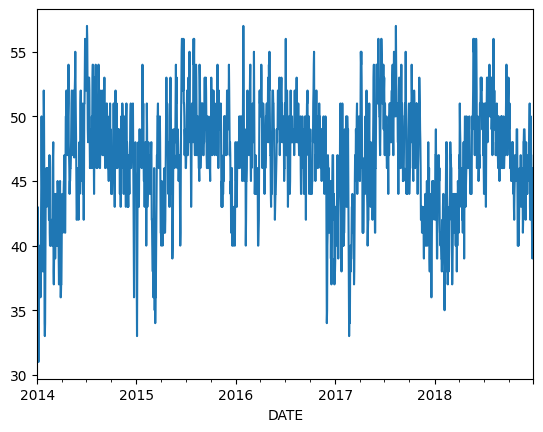

In [ ]:
weather['AvgTemp'].plot()

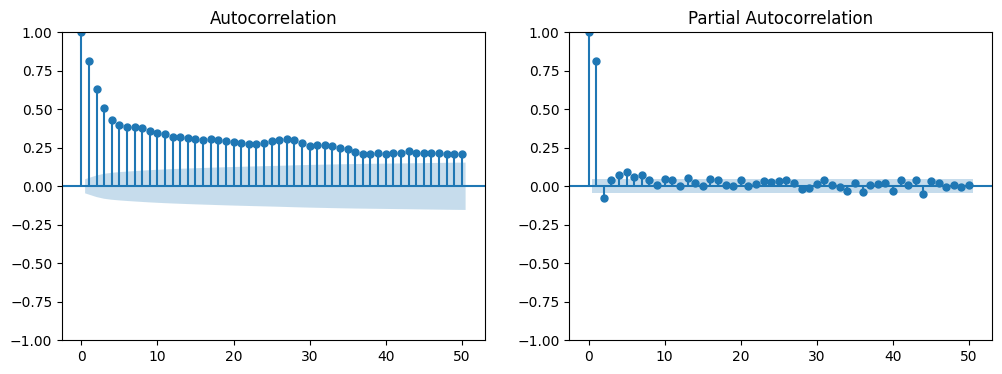

In [ ]:
# ---- 2) Visual ACF / PACF (to guide p/q) ----
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(weather['AvgTemp'], lags=50, ax=axes[0])
plot_pacf(weather['AvgTemp'], lags=50, ax=axes[1])
plt.show()

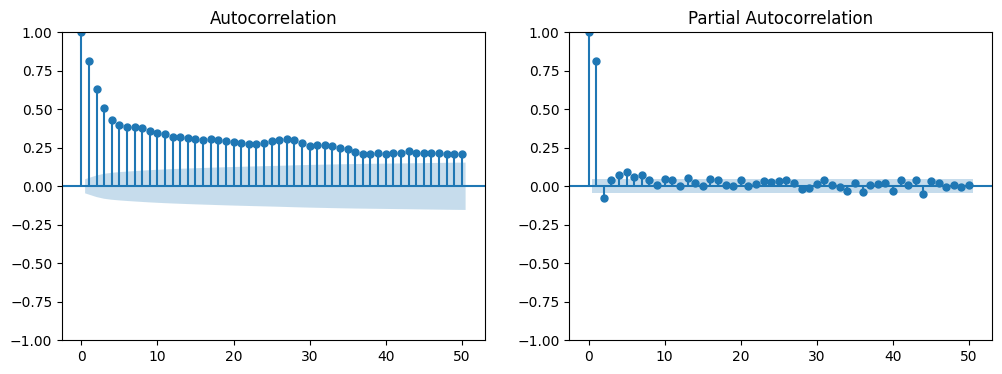

In [ ]:
fig

In [ ]:
def see_acf_pacf_plots(timeseries): # assuming timeseries has no null
  # ---- 2) Visual ACF / PACF (to guide p/q) ----
  fig, axes = plt.subplots(1,2, figsize=(12,4))
  plot_acf(timeseries, lags=50, ax=axes[0])
  plot_pacf(timeseries, lags=50, ax=axes[1])
  plt.show()

[Geeks for geeks acf pacf link](https://www.geeksforgeeks.org/r-machine-learning/autocorrelation-and-partial-autocorrelation/)

but it uses R programming



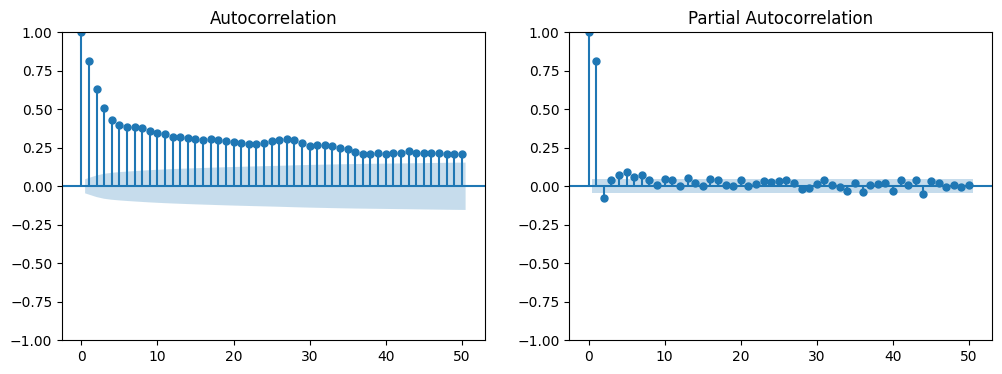

In [ ]:
see_acf_pacf_plots(weather['AvgTemp'])

In [ ]:
plt.show()

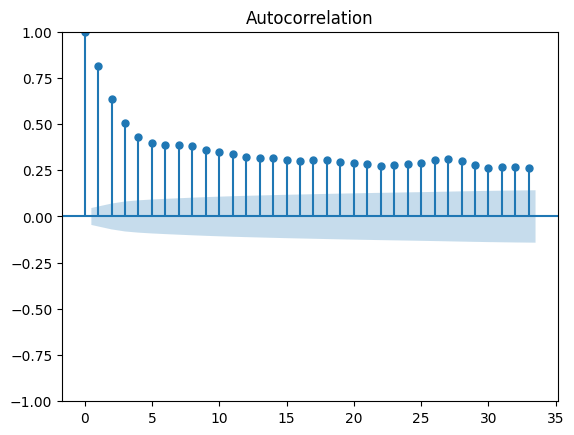

In [ ]:
plot_acf(weather['AvgTemp']) # it returns fig and calls show() so 2 times printed
plt.show()

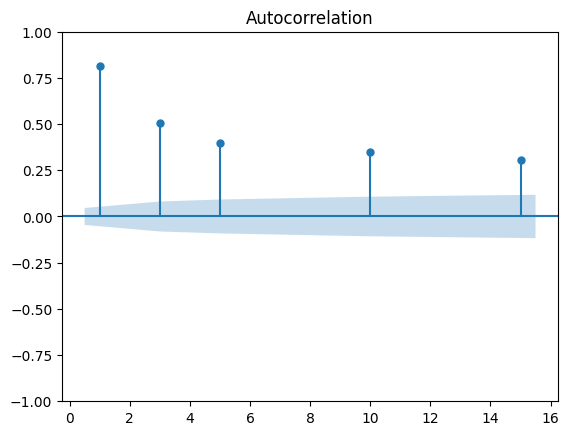

In [ ]:
plot_acf(weather['AvgTemp'], lags=[1, 3, 5, 10, 15])
plt.show()

Default lags :

nlags : int, optional
    
  Number of lags to return autocorrelation for.
    
  If not provided,
uses `min(10 * np.log10(nobs), nobs - 1)`. The returned value
includes lag 0 (ie., 1) so size of the acf vector is (nlags + 1,).

nobs = number of observations in your time series

In [ ]:
from statsmodels.tsa.stattools import acf, pacf

In [ ]:
acf_values1 = acf(weather['AvgTemp'], fft=False)  # default lags=None


In [ ]:
acf_values1

array([1.        , 0.81276819, 0.6344214 , 0.50560258, 0.430682  ,
       0.39923408, 0.38654025, 0.38470272, 0.37917868, 0.36025189,
       0.34697891, 0.33830369, 0.32192895, 0.31772583, 0.31428532,
       0.30392528, 0.30186971, 0.30540414, 0.30304309, 0.2924358 ,
       0.2886606 , 0.28174603, 0.27552641, 0.27660182, 0.28210034,
       0.29188493, 0.3035726 , 0.3102204 , 0.3000378 , 0.27889365,
       0.2637524 , 0.26568902, 0.26811177])

In [ ]:
len(weather)

1825

In [ ]:
len(acf_values1)

33

In [ ]:
acf(weather['AvgTemp'], nlags=5, fft=False)

array([1.        , 0.81276819, 0.6344214 , 0.50560258, 0.430682  ,
       0.39923408])

ARIMA(p,d,q):

p → order of AR (AutoRegressive)

d → order of differencing (to make series stationary)

q → order of MA (Moving Average)

ACF → helps find q (MA order)

PACF → helps find p (AR order)

in plots

X-axis → lags

Y-axis → correlation coefficient (ρ)

Blue shaded region → 95% confidence interval

Bars outside → statistically significant

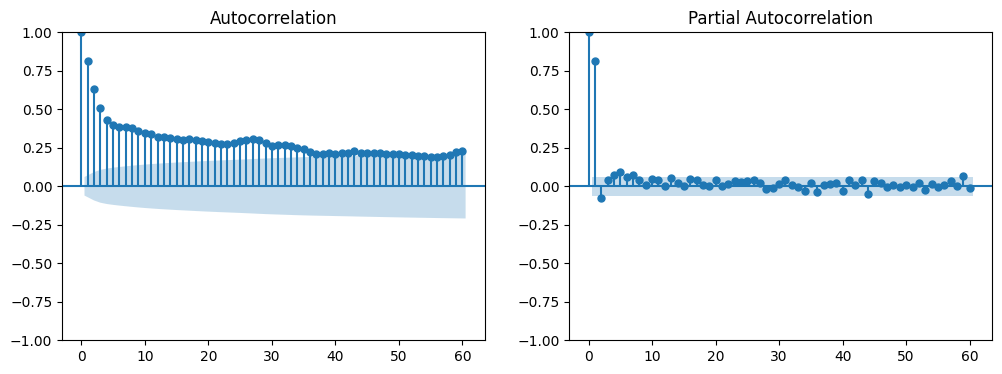

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
# use alpha=0.01 for 99% CI (wider bands)
_ = plot_acf(weather['AvgTemp'], lags=60, ax=axes[0], alpha=0.01)
_ = plot_pacf(weather['AvgTemp'], lags=60, ax=axes[1], alpha=0.01)
plt.show()

In [ ]:
plot_pacf(weather['AvgTemp'], lags=60, ax=axes[1], alpha=0.001)
plt.show()

In [ ]:
def find_p_q_1(timeseries):
  acf_vals = acf(timeseries, nlags=50)
  pacf_vals = pacf(timeseries, nlags=50)
  n = len(timeseries)
  conf_int = 1.96 / np.sqrt(n)
  p_candidates = np.where(np.abs(pacf_vals[1:]) > conf_int)[0] + 1  # skip lag 0
  if len(p_candidates) > 0:
    p = max(p_candidates)  # last significant lag
  else:
    p = 0
  q_candidates = np.where(np.abs(acf_vals[1:]) > conf_int)[0] + 1  # skip lag 0
  if len(q_candidates) > 0:
    q = max(q_candidates)  # last significant lag
  else:
    q = 0
  print(f"Suggested AR order p = {p}")
  print(f"Suggested MA order q = {q}")

In [ ]:
find_p_q_1(weather['AvgTemp'])

Suggested AR order p = 44
Suggested MA order q = 50


In [ ]:
from statsmodels.tsa.stattools import acf, pacf
import numpy as np

def find_p_q(timeseries, nlags=50, alpha=0.05):
  # Compute ACF and PACF with confidence intervals
  acf_vals, acf_conf = acf(timeseries, nlags=nlags, alpha=alpha, fft=False)
  pacf_vals, pacf_conf = pacf(timeseries, nlags=nlags, alpha=alpha)

  # Extract lower and upper confidence bounds
  acf_lower, acf_upper = acf_conf[:, 0], acf_conf[:, 1]
  pacf_lower, pacf_upper = pacf_conf[:, 0], pacf_conf[:, 1]

  # Identify significant lags (where zero is outside CI)
  p_candidates = np.where((pacf_lower[1:] > 0) | (pacf_upper[1:] < 0))[0] + 1
  q_candidates = np.where((acf_lower[1:] > 0) | (acf_upper[1:] < 0))[0] + 1

  # Choose last significant lag as order
  p = max(p_candidates) if len(p_candidates) > 0 else 0
  q = max(q_candidates) if len(q_candidates) > 0 else 0

  print(f"Suggested AR order (p) = {p}")
  print(f"Suggested MA order (q) = {q}")
  return p, q

In [ ]:
find_p_q(weather['AvgTemp'], 60, 0.01)

Suggested AR order (p) = 59
Suggested MA order (q) = 60


(59, 60)

In [ ]:
find_p_q(weather['AvgTemp'], 60, 0.1)

Suggested AR order (p) = 59
Suggested MA order (q) = 60


(59, 60)

In [ ]:
find_p_q(weather['AvgTemp'], 60)

Suggested AR order (p) = 59
Suggested MA order (q) = 60


(59, 60)

In [ ]:
find_p_q(weather['AvgTemp'], 60, 0.001)

Suggested AR order (p) = 5
Suggested MA order (q) = 34


(5, 34)

In [ ]:
# ---- 4) Compare candidate ARIMA orders by AIC/BIC and RMSE on holdout ----
from math import sqrt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

candidates = [(3,0,2), (1,0,5), (0,0,5), (2,0,5)]  # given orders
results = []

# Train / test split (time-series)
n = len(weather['AvgTemp'])
train_size = int(n * 0.8)
train = weather['AvgTemp'].iloc[:train_size]
test = weather['AvgTemp'].iloc[train_size:]

for order in candidates:
  p, d, q = order
  try:
    model = ARIMA(train, order=order).fit()
    aic = model.aic
    bic = model.bic

    # one-step rolling forecast
    history = train.copy()
    preds = []
    for t in range(len(test)):
      model_t = ARIMA(history, order=order).fit()
      yhat = model_t.forecast(steps=1)
      preds.append(float(yhat))
      history = pd.concat([history, pd.Series(test.iloc[t], index=[test.index[t]])])

    rmse = sqrt(mean_squared_error(test, preds))
    results.append({'order': order, 'aic': aic, 'bic': bic, 'rmse': rmse})
    print(order, 'AIC:', aic, 'BIC:', bic, 'RMSE:', rmse)

  except Exception as e:
    print('Order', order, 'failed:', e)

results_df = pd.DataFrame(results).sort_values(by='aic')
print(results_df)

(3, 0, 2) AIC: 6707.708023265748 BIC: 6744.711365268665 RMSE: 2.1908656828721904
(1, 0, 5) AIC: 6709.289763593422 BIC: 6751.579297311041 RMSE: 2.1867246119185006
(0, 0, 5) AIC: 6795.4149688816 BIC: 6832.418310884516 RMSE: 2.330422808479142
(2, 0, 5) AIC: 6709.636502656236 BIC: 6757.212228088558 RMSE: 2.188482277550223
       order          aic          bic      rmse
0  (3, 0, 2)  6707.708023  6744.711365  2.190866
1  (1, 0, 5)  6709.289764  6751.579297  2.186725
3  (2, 0, 5)  6709.636503  6757.212228  2.188482
2  (0, 0, 5)  6795.414969  6832.418311  2.330423


---

###### **1️⃣ Purpose of the code**

You are comparing **candidate ARIMA models** `(p,d,q)` based on:

1. **AIC** – Akaike Information Criterion (lower is better)
2. **BIC** – Bayesian Information Criterion (lower is better)
3. **RMSE** – Prediction error on **holdout/test set**

---

###### **2️⃣ Train-test split**

* 80% of data → **train**
* 20% of data → **test/holdout**
* Important for **time series**: **do NOT shuffle**, must keep chronological order

---

##### **3️⃣ Loop over candidate ARIMA orders**

* You are **evaluating multiple ARIMA models** given in the `candidates` list - options in question

---

##### **4️⃣ Fit model on training data**

before loop for test

* Fit ARIMA on **train set**
* Extract **AIC and BIC** (based on likelihood of train data)

---

###### **5️⃣ One-step rolling forecast for test**


**Why a loop for test ?**

* **Time series forecast must respect order**: you can’t use future values to predict past.
* **One-step rolling forecast**:

  1. Fit model on **current history**
  2. Forecast **next time point**
  3. Compare prediction to **actual value**
  4. Append the actual value to history → use it for next forecast
* This simulates **realistic forecasting**, where you only know the past, not future.

> Without this loop, you’d be doing **static forecast** (forecast entire test at once), which can be less accurate for ARIMA models.

---

###### ✅ **Key takeaway**

* **Loop over test set** = simulates **step-by-step real-time prediction**
* **history.append(actual)** = makes forecast **rolling**, so each prediction only uses past data
* This is the correct way to **evaluate ARIMA models on holdout set**

---

In [ ]:
# !pip install numpy==1.26.4 pmdarima==2.0.4

In [ ]:
from pmdarima import auto_arima


In [ ]:

auto_arima(weather['AvgTemp'], seasonal=False, trace=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=8574.192, Time=0.46 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=19234.261, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=16832.143, Time=0.11 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,2)(0,0,0)[0]             : AIC=8501.686, Time=0.12 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,5)(0,0,0)[0]             : AIC=8333.509, Time=1.39 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,4)(0,0,0)[0] intercept   : AIC=8334.935, Time=3.62 sec

Best model:  ARIMA(2,0,4)(0,0,0)[0]          
Total fit time: 12.972 seconds


ARIMA(order=(2, 0, 4), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

Best model:  ARIMA(2,0,4)(0,0,0)[0]  

but this is not correct since we gaev seasonal False, but we can see season in our data

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
auto_arima(weather['AvgTemp'], seasonal=True, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=8367.815, Time=2.97 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=10366.472, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=8392.171, Time=0.17 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=9157.155, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=19234.261, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=8383.250, Time=1.17 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=8383.888, Time=2.09 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=8374.508, Time=1.92 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=8348.785, Time=2.95 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=8359.391, Time=1.82 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=8346.808, Time=2.40 sec
 ARIMA(4,0,3)(0,0,0)[0] intercept   : AIC=8358.130, Time=3.84 sec
 ARIMA(3,0,4)(0,0,0)[0] intercept   : AIC=8345.945, Time=3.56 sec
 ARIMA(2,0,4)(0,0,0)[0] intercept   : AIC=8334.935, Time=2.87 sec
 ARIMA(1,0,4)(0,0,0)[0] interce

ARIMA(order=(1, 0, 5), scoring_args={}, suppress_warnings=True)

In [ ]:
auto_arima(weather['AvgTemp'])

ARIMA(order=(1, 0, 5), scoring_args={}, suppress_warnings=True)

In [ ]:
# use the below lines to set real seasonality as our seasoanlity is 365 days once but it will take long time

# auto_arima_365 = auto_arima(weather['AvgTemp'], seasonal=True, m=365, stepwise=True,
#                      max_p=5, max_q=5, max_P=5, max_Q=5, trace=True)

ARIMA(1,0,5)(0,0,0)[0] intercept

is correct since by default seasonal is true

in manual code also (1,0,5) comes 2nd good model with best RMSE than any other. so we can choose this

also manual code uses only train data for AIC. auto arima uses full data.

In [ ]:
# auto arima needs without null series

5. Answer - ARIMA(1,0,5)

6) What is the ADF(Augmented Dickey Fuller Test) used for detecting?
- Normality
- Independence
- Stationary
- Seasonality

In the Augmented Dickey-Fuller (ADF) test, the **null hypothesis** $(H_{0})$ is that a time series has a unit root, which means it is **non-stationary.**

the **p-value in the ADF test** is the **probability of observing the test statistic (or more extreme) if the null hypothesis is true**.

---

##### 1️⃣ Null hypothesis (H₀) in ADF test

* H₀: The series **has a unit root** → it is **non-stationary**.

##### 2️⃣ Alternative hypothesis (H₁)

* H₁: The series **does not have a unit root** → it is **stationary**.

---

##### 3️⃣ Interpreting the p-value

* **p-value < significance level (e.g., 0.05)**
  → Low probability that H₀ is true given the data
  → **Reject H₀ → conclude the series is stationary**

* **p-value ≥ significance level**
  → High probability that H₀ could be true
  → **Fail to reject H₀ → series may be non-stationary**

---

###### ✅ In short

> p-value = probability that the series is non-stationary (i.e., H₀ is true).
> Smaller p → less likely the series is non-stationary → more likely stationary.

---

**Answer:** Stationary ✅

**Explanation:** The Augmented Dickey-Fuller (ADF) test is used to check whether a time series is **stationary** — meaning its statistical properties (mean, variance, autocorrelation) do not change over time.


6. Answer - Stationary

7) Which of the Statements is True?
- p>0.5 Data is stationary
- p<0.05 Data is stationary
- p>0.05, Data is stationary
- p<0.5 Data is Not Stationary

In statistics, if the p-value is less than or equal to (p ≤ α), you reject the null hypothesis.

**Answer:** p < 0.05 → Data is stationary ✅

**Explanation:**

* In the ADF test, the **null hypothesis (H₀)** is that the series is **non-stationary**.
* If **p < 0.05**, we **reject H₀**, concluding the series is **stationary**.


7. Answer - `p<0.05 Data is stationary`

8) Determine the Average Error in Prediction By the Model?
- 6-8%
- 1-3%
- 3-6%
- 8-11%

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
model.param_names

['const',
 'ar.L1',
 'ar.L2',
 'ma.L1',
 'ma.L2',
 'ma.L3',
 'ma.L4',
 'ma.L5',
 'sigma2']

In [ ]:
model.model_orders

{'trend': 0,
 'exog': 1,
 'ar': 2,
 'ma': 5,
 'seasonal_ar': 0,
 'seasonal_ma': 0,
 'reduced_ar': 2,
 'reduced_ma': 5,
 'exog_variance': 0,
 'measurement_variance': 0,
 'variance': 1}

In [ ]:
# last model is 2,0,5 not useful

In [ ]:
# --- Data ---
series_avg = weather['AvgTemp']  # your AvgTemp series

# --- Train/Test Split ---
n = len(series_avg)
train_size = int(n * 0.8)
train = series_avg.iloc[:train_size]
test = series_avg.iloc[train_size:]

# --- Fit ARIMA Model on Train ---
order = (1, 0, 5)  # example order, use your best candidate
model = ARIMA(train, order=order).fit()

# --- Predictions ---
# In-sample predictions for train
train_pred = model.predict(start=train.index[0], end=train.index[-1])

# Out-of-sample predictions for test
# dynamic=False: uses actual past values (train + previous test points if provided)
test_pred = model.predict(start=test.index[0], end=test.index[-1], dynamic=False)

# --- Calculate MAPE ---
train_mape = mean_absolute_percentage_error(train, train_pred) * 100
test_mape = mean_absolute_percentage_error(test, test_pred) * 100

print(f"Train MAPE: {train_mape:.2f}%")
print(f"Test MAPE: {test_mape:.2f}%")

Train MAPE: 4.09%
Test MAPE: 6.64%


In [ ]:
test_pred_1 = model.predict(start=len(train),end=len(train)+len(test)-1) # default dynamic false
mean_absolute_percentage_error(test, test_pred_1) * 100

6.635779060503132

In [ ]:
test_pred_2 = model.predict(start=len(train),end=len(train)+len(test)-1, dynamic=True) # not using previous data
mean_absolute_percentage_error(test, test_pred_2) * 100

6.635779060503132

8. Answer - 6-8%

**8. Given correct answer as per answer key - `1-3%`**

9) What is the Coefficient of AR of the above model for the target variable Avg Temp?
- 0.90 to 1.0
- 0.60 to 0.70
- 0.50 to 0.60
- 0.30 to 0.40

Not exactly — the **coefficient of AR** is **not the same as `p`**. Let me clarify:

---

###### **1️⃣ ARIMA model recap**

* ARIMA(p,d,q):

  * **p** = number of AR (Auto-Regressive) terms
  * **d** = number of differences to make series stationary
  * **q** = number of MA (Moving Average) terms

* Each **AR term** has a **coefficient** that tells how much past values contribute to the current value.

---

###### **2️⃣ Coefficient of AR**

* For **AR(1)**, the model is:

$
y_t = \phi_1 y_{t-1} + \epsilon_t
$

* Here, $\phi_1$ is the **AR coefficient**
* **p** = 1 → number of AR terms
* **Coefficient value** = 0.9, 0.6, etc., tells **strength of autocorrelation**
* So **p** tells “how many AR terms,” **coefficient tells how strong each term is**

---

###### **3️⃣ How to check it in code**

```python
# model = ARIMA(train, order=(1,0,5)).fit()
print(model.params)  # shows coefficients
```

**Example output:**

```
ar.L1    0.93
ma.L1   -0.41
ma.L2    0.15
ma.L3   -0.05
ma.L4    0.02
ma.L5   -0.01
sigma2   1.23
```

* `ar.L1` → coefficient of **lag 1 AR term**
* Values between 0 and 1 indicate **positive correlation with past value**
* So if `ar.L1` ≈ 0.93 → answer would be **0.90 to 1.0**

---

✅ **Key takeaway:**

* **p** = number of AR terms
* **AR coefficient** = the weight/strength of each AR term
* The quiz is asking about **coefficient**, not p.

---

---

###### **1️⃣ AR (Auto-Regressive)**

* AR = “I predict the current value using **past values**.”
* Formula (AR(1)):

$
y_t = \phi_1 y_{t-1} + \epsilon_t
$

* The **coefficient φ** tells how strongly the past value affects today.
* **Captures short-term correlation**, not necessarily trend or seasonality.

---

###### **2️⃣ MA (Moving Average)**

* MA = “I predict the current value using **past errors/residuals**.”
* Formula (MA(1)):

$
y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1}
$

* θ = coefficient of past error
* Captures **noise or shocks from previous time points**.
* Also **not trend or seasonality directly**, just smooths out random fluctuations.

---

###### **3️⃣ Trend vs Seasonality**

* **Trend** → overall increasing or decreasing pattern over time

* **Seasonality** → repeating pattern at fixed intervals (e.g., daily, yearly)

* **ARIMA alone** can model trend **after differencing (d)**

* **Seasonal ARIMA (SARIMA)** adds extra AR/MA for **seasonal cycles**

---

###### **Simple analogy**

| Component          | What it does                                   |
| ------------------ | ---------------------------------------------- |
| AR                 | Looks at **past values** to predict today      |
| MA                 | Looks at **past errors** to correct prediction |
| d                  | Difference to remove **trend**                 |
| Seasonal (P,D,Q,m) | Extra AR/MA/d for **seasonal patterns**        |

---

✅ **Key point:**

* **AR ≠ seasonal**, **MA ≠ trend**
* AR & MA capture **short-term correlation and noise**, while **differencing** captures trend and **seasonal terms** capture seasonality.

---


---

###### **What is the AR coefficient?**

Think of **AR(1) model**:

$
\text{Today’s value} = (\text{AR coefficient}) \times \text{Yesterday’s value} + \text{error}
$

* The **AR coefficient** tells **how much the past value affects the current value**.
* Value range: usually **-1 to 1**

  * Close to 1 → today’s value almost same as yesterday’s (strong positive effect)
  * Close to 0 → yesterday doesn’t matter much
  * Negative → yesterday has opposite effect

---

**Example**

If AR coefficient = 0.9:

$
\text{Today’s AvgTemp} \approx 0.9 \times \text{Yesterday’s AvgTemp} + \text{small error}
$

* Means **today’s temperature is strongly influenced by yesterday**.

If AR coefficient = 0.4:

$
\text{Today’s AvgTemp} \approx 0.4 \times \text{Yesterday’s AvgTemp} + \text{error}
$

* Past matters **less**, more random variation today.

---

✅ **Key point:**

* AR coefficient = **strength of relationship with previous value(s)**
* Not the same as **p**, which just tells **how many past values you are using**.

---

I can also draw a **tiny diagram showing how yesterday affects today for different AR coefficients**, so it’s super visual. Do you want me to do that?


In [ ]:
model.params # already fitted model

,0
const,46.536361
ar.L1,0.984599
ma.L1,-0.136123
ma.L2,-0.244078
ma.L3,-0.198100
ma.L4,-0.149367
ma.L5,-0.061957
sigma2,5.729023


In [ ]:
model.params.index

Index(['const', 'ar.L1', 'ma.L1', 'ma.L2', 'ma.L3', 'ma.L4', 'ma.L5',
       'sigma2'],
      dtype='object')

In [ ]:
ar_list_index = [s for s in model.params.index.to_list() if s.startswith('ar.')]

In [ ]:
ar_list_index

['ar.L1']

In [ ]:
model.params[ar_list_index]

,0
ar.L1,0.984599


more than 0.90

max it can be 1 only

9. Answer - `0.90 to 1.0`

10) Which conditions need to be satisfied to refer to the time series as stationary.
- Mean is constant and does not depend on time
- The time series under considerations is a finite variance process
- Autocovariance function depends on s and t only through their difference |s-t| (where t and s are moments in time)
- None of the above

The correct answer is:

**All three conditions must be satisfied** for a time series to be **strictly stationary**.

* **Mean is constant** → the average value does not change over time ✅
* **Finite variance** → the variability does not explode over time ✅
* **Autocovariance depends only on lag |s-t|** → correlation structure is constant over time ✅

So, from your options, the ones listed describe the **requirements of a stationary time series**.

**Answer (based on given options):**

* If “None of the above” is the only “all together” option, **it is NOT correct** — the first three statements are the conditions.

---

In **simple terms:**

> A stationary series has **constant mean**, **constant variance**, and **correlations depend only on time difference, not actual time**.



---

###### **Autocovariance depending on |s-t|**

* Suppose you have a time series (X_t).
* The **autocovariance** between two points in time (s) and (t) is:

$
\text{Cov}(X_s, X_t) = E[(X_s - \mu)(X_t - \mu)]
$

* For a **stationary series**, this **does not depend on the actual times** (s) and (t), but only on how far apart they are:

$
\text{Cov}(X_s, X_t) = f(|t - s|)
$

* That is, **only the lag (difference) matters**, not the absolute time.

---

###### **Example**

* Time series: daily temperature
* Covariance between day 1 and day 3 = Cov(day 100 and day 102)

  * Why? Because **lag = 2 days** in both cases
  * The actual day numbers don’t matter

---

###### **In simple words**

> The relationship between two points in the series depends **only on how far apart they are**, not on **which exact days** they are.

---


the intuition behind using **rolling mean or differencing** to make a series stationary:

---

**1️⃣ Correcting the mean**

* When you subtract the rolling mean (or take differences), the **mean becomes roughly constant over time**.
* This directly addresses the first condition of stationarity.

---

**2️⃣ Correcting the variance**

* If the variance was changing slowly over time, removing trend/rolling mean also tends to **stabilize the variance** (though sometimes you might also do a transformation like `log` or `sqrt` to fully stabilize it).

---

**3️⃣ Effect on autocovariance**

* Autocovariance depends on deviations from the mean:
  [
  \text{Cov}(X_s, X_t) = E[(X_s - \mu)(X_t - \mu)]
  ]
* If the mean is constant and variance stable, the autocovariance **depends mostly on the lag**, not absolute time.
* So **differencing or removing rolling mean indirectly helps satisfy the autocovariance condition**.

---

✅ **Key takeaway:**

* By correcting **mean** and **variance**, you mostly handle all practical aspects of stationarity.
* That’s why in quizzes, **“mean is constant”** is often marked as the main condition.

---


**So, most straight forward answer for this quesion is STATIONARY means constant mean, NO ROLLING MEAN.**

**Essential step in detrending is removing rolling mean**

10. Answer - Mean is constant and does not depend on time

11) IF we have observed the time series Y1, Y2, ..., Yt and the forecast error et(l) = Yt+l − bYt(l) has  mean zero, the MMSE forecast bYt(l) can be referred as:
- Unbiased.
- Consistent.
- Complementary.
- Stationary.

Observed means ACTUAL data

---

###### **Step 1: Observed series**

* You have a time series:

$
Y_1, Y_2, \dots, Y_t
$

* These are the **actual observed values** — the real data you collected. ✅

---

###### **Step 2: Forecasting**

* Suppose you want to forecast (l)-steps ahead ((Y_{t+l})) using the information up to time (t).
* Let (\hat{Y}_t(l)) (or in your notation (bY_t(l))) be the forecast.

$
\hat{Y}*t(l) = \text{your predicted value of } Y*{t+l} \text{ based on past data}
$

---

###### **Step 3: Forecast error**

* The error is the **difference between what actually happens and what you predicted**:

$
e_t(l) = Y_{t+l} - \hat{Y}_t(l)
$

* This is called the **forecast error**.

---

###### **Step 4: Mean of forecast error**

* If the **expected value** of this error is zero:

$
E[e_t(l)] = 0
$

* It means that **on average, your forecasts are correct**: you are not systematically overestimating or underestimating.

---

###### **Step 5: Interpretation**

* This is exactly what **unbiased** means in forecasting:

> The forecast is **unbiased** if the average error over many forecasts is zero.

* Other options:

  * **Consistent** → applies to parameter estimates converging to true values as sample size increases
  * **Stationary** → property of the series, not forecast
  * **Complementary** → not relevant

---

###### ✅ **Key takeaway**

* Observed = actual data ((Y_1, Y_2, \dots, Y_t))
* Forecast = prediction ((\hat{Y}_t(l)))
* Forecast error = actual − predicted ((e_t(l) = Y_{t+l} - \hat{Y}_t(l)))
* Mean zero error → **unbiased forecast**

---

If you want, I can **draw a tiny diagram showing observed values, forecast, and error**, so “mean zero” is visual.

Do you want me to do that?


Why the other options are incorrect:
- Consistent: Refers to an estimator whose bias approaches zero as sample size increases - not directly related to forecast error having mean zero

- Complementary: Not a standard statistical property for forecasts

- Stationary: Refers to time series properties (constant mean, variance over time), not forecast bias properties

Consistency is theoretical assumption for large models as n -> infinity, the predicted will be arbitarily close as actual values (almost close)

---

###### **1️⃣ Training and Test Data**

* **Training data:**

$
Y_1, Y_2, \dots, Y_t
$

These are the values you fit into the model using `.fit()`.

* **Test data:**

$
Y_{t+1}, \dots, Y_{t+l}
$

These are the future values you want to predict (what you split as `test` in your code).

---

###### **2️⃣ Model Prediction**

* The model predicts:

$
\hat{Y}*{t+1}, \dots, \hat{Y}*{t+l}
$

* The model internally chooses parameters (like AR, MA coefficients) to **minimize the Mean Squared Error (MSE)** on the training data.
* This optimization **happens inside `.fit()`**; we don’t see it directly.

---

###### **3️⃣ Forecast Error**

* After predicting, you can calculate the **forecast error** for the test set:

$
e_t(l) = Y_{t+i} - \hat{Y}_{t+i}, \quad i=1 \dots l
$

* This is an **array of size = test set**.

---

###### **4️⃣ Unbiased Property**

* If the forecast is **MMSE**, the **mean of the errors**:

$
\text{mean}(e_t) = 0
$

* In practice:

```python
errors = test - y_pred
np.mean(errors)  # should be close to 0 for unbiased
```

* This shows that the forecast is **unbiased**: it does not systematically overestimate or underestimate.

---

✅ So in your code, you can **directly check biasedness** by taking the mean of the forecast errors on the test set. If it is 0, it is unbiased

---


---

###### **1️⃣ Model `.fit()`**

* **Purpose:** Learn the **model parameters** from the **training data** (Y_1, \dots, Y_t).
* **What happens:**

  * ARIMA/ARMA/other models find the best coefficients (AR, MA, etc.) that **minimize the MSE on the training data**.
  * This is done **once during `.fit()`**.
* **Important:** `.fit()` **does not look at the test data** (Y_{t+1}, \dots, Y_{t+l}).

---

###### **2️⃣ Model `.predict()` or `.forecast()`**

* **Purpose:** Generate **predictions for future time points**.
* **What happens:**

  * The model uses the **parameters learned from `.fit()`**.
  * It applies the model formula recursively to compute $\hat{Y}_{t+1}, \dots, \hat{Y}_{t+l}$.
* **Important:** No parameter optimization happens here. `.predict()` just **applies the learned model** to new points.

---

###### **✅ Key Takeaway**

| Step         | ---Data Used---             | Optimization?       | Output                                          |
| ------------ | ------------------------------- | ------------------- | ----------------------------------------------- |
| `.fit()`     | Training $Y_1..Y_t$      | Yes (MSE minimized) | Model parameters learned                        |
| `.predict()` | Future $Y_{t+1}..Y_{t+l}$ | No                  | Predicted values $\hat{Y}_{t+1}..\hat{Y}_{t+l}$ |

---

So to answer your exact question:

> because that data is given in predict only. yt+1 to yt+l

**No**, the MSE minimization happens during `.fit()` on the **training data**, not on the future data. `.predict()` simply uses those learned parameters to generate the forecast.

---


In [ ]:
model_error = test - test_pred # this is signed error
# not Absolute error., so we cant use mean absolute error directly

In [ ]:
model_error

,0
DATE,
2017-12-31,0.200608
2018-01-01,0.317140
2018-01-02,0.424161
2018-01-03,-1.449660
2018-01-04,3.568289
...,...
2018-12-26,-6.523991
2018-12-27,-7.524181
2018-12-28,-6.524369


In [ ]:
np.mean(model_error)

0.3576161099613261

11. Answer - Unbiased.


**11. The given correct answer as per answer key - Stationary**

12) Which of the following is a seasonality Detection Technique for Time Series Data?

1. Autocorrelation

2. Multiple box

- None of the above
- Only 1
- Only 2
- Both 1 and 2

The correct answer is:

**Both 1 and 2** ✅

###### **Explanation:**

1. **Autocorrelation**

   * Measures the correlation of a time series with its **lagged versions**.
   * Peaks at regular lags indicate **repeating patterns → seasonality**.

2. **Multiple Box (Box Plot)**

   * Box plots grouped by **time cycles** (e.g., months, weekdays) can **visually reveal seasonality**.

So both are **techniques used to detect seasonality** in time series.


if the **ACF shows a clear peak at lag 12** and it **repeats at multiples of 12** (like 24, 36…), that is strong evidence of seasonality with a period of 12 months. ✅

* **Single peak at lag 12 only:** could indicate a correlation at that lag, but by itself it may **not be enough** — you want to see it **repeating at multiples of 12** to be confident it’s truly seasonal rather than just a coincidence.
* **Repeating peaks every 12 lags** → confirms **annual seasonality**.

So yes, **peak at 12 + repeating at 24, 36…** is enough to declare seasonality with period 12.


<Axes: xlabel='DATE'>

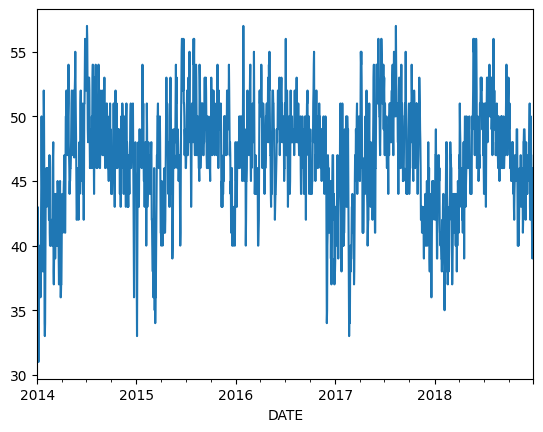

In [ ]:
weather['AvgTemp'].plot()

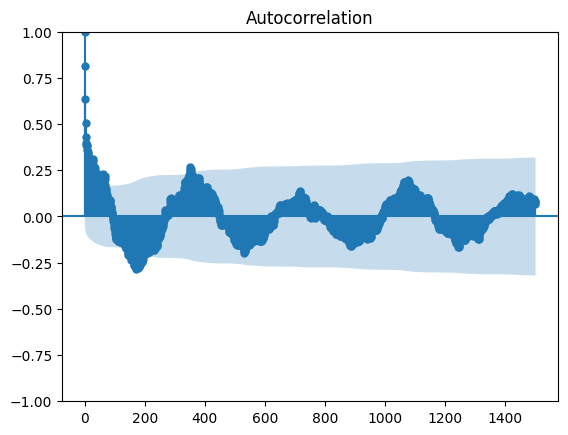

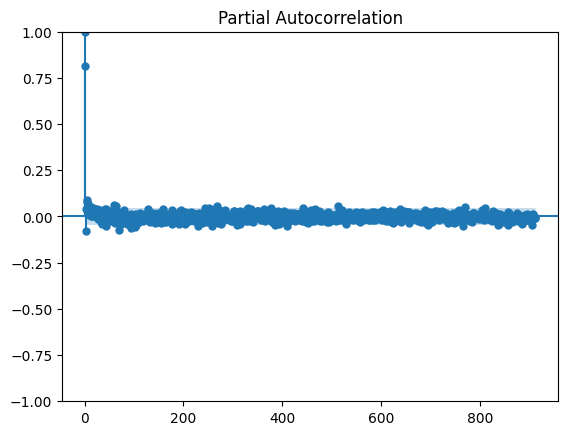

In [ ]:
plot_acf(weather['AvgTemp'], lags=1500) # our season is 365 days. so we cant get that in lag less than 365
plot_pacf(weather['AvgTemp'], lags=912)
plt.show()

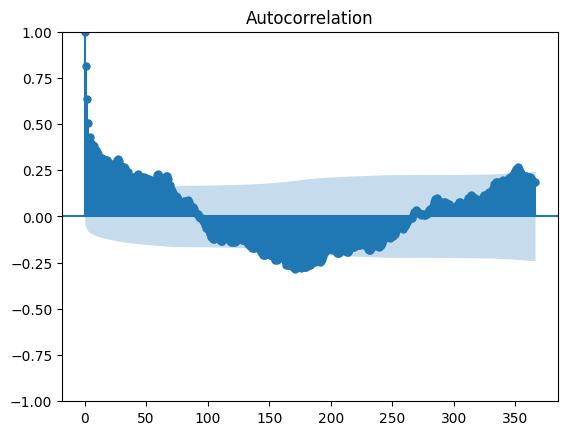

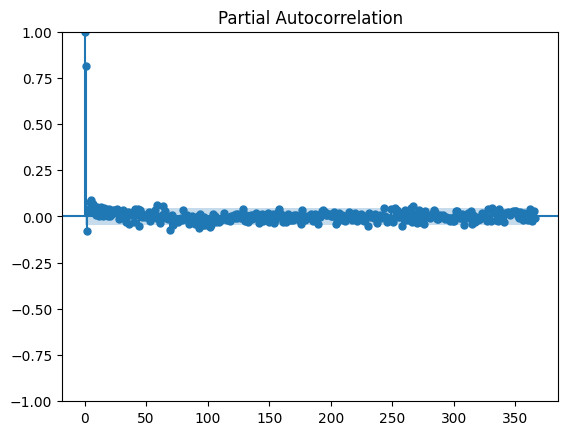

In [ ]:
plot_acf(weather['AvgTemp'], lags=366) # our season is 365 days. so we cant get that in lag less than 365
plot_pacf(weather['AvgTemp'], lags=366)
plt.show()

**every half year it is negatively correlated**

**every one year it is positively correlated**

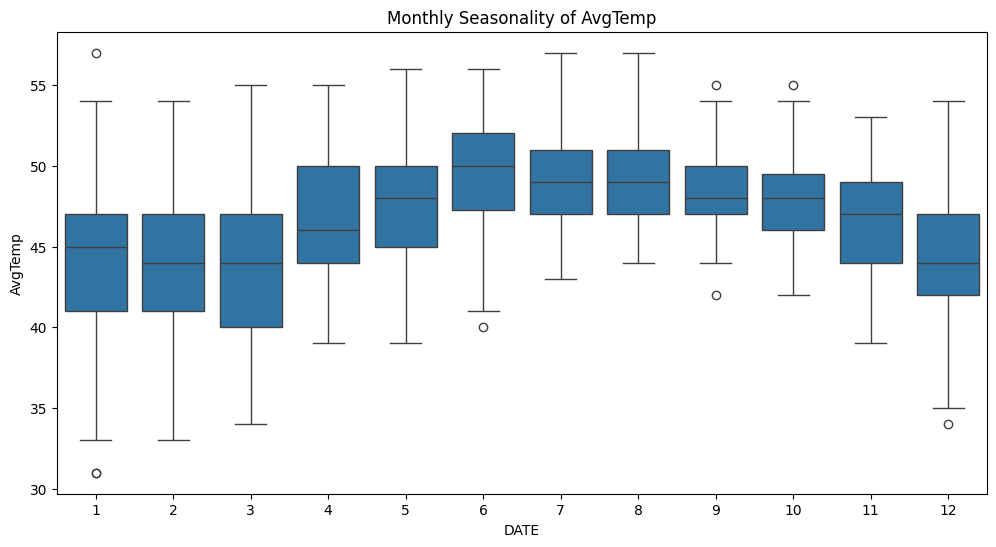

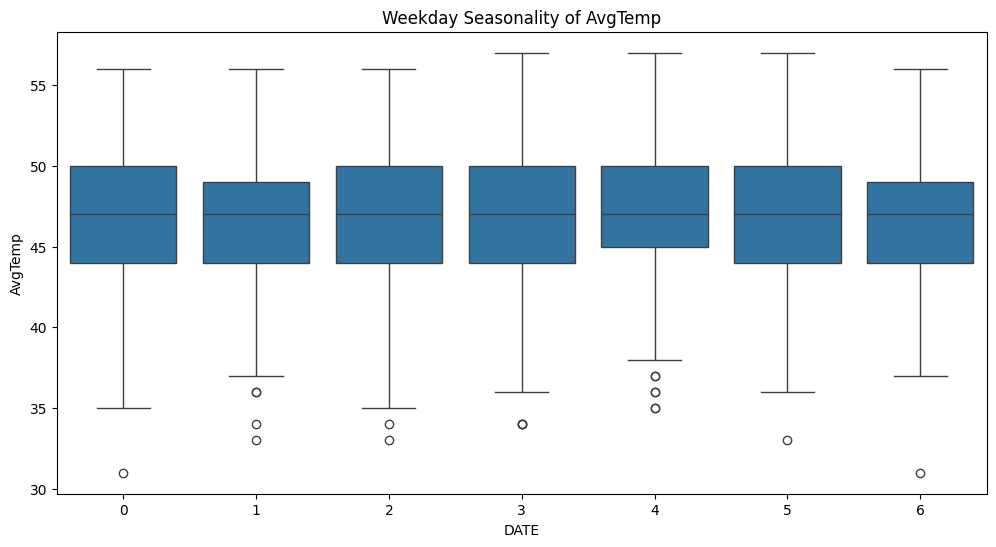

In [ ]:
# Monthly boxplot
plt.figure(figsize=(12,6))
sns.boxplot(x=weather.index.month, y=weather['AvgTemp'])
plt.title("Monthly Seasonality of AvgTemp")
plt.show()

# Weekly boxplot (optional)
plt.figure(figsize=(12,6))
sns.boxplot(x=weather.index.weekday, y=weather['AvgTemp'])
plt.title("Weekday Seasonality of AvgTemp")
plt.show()


<Axes: xlabel='DATE', ylabel='AvgTemp'>

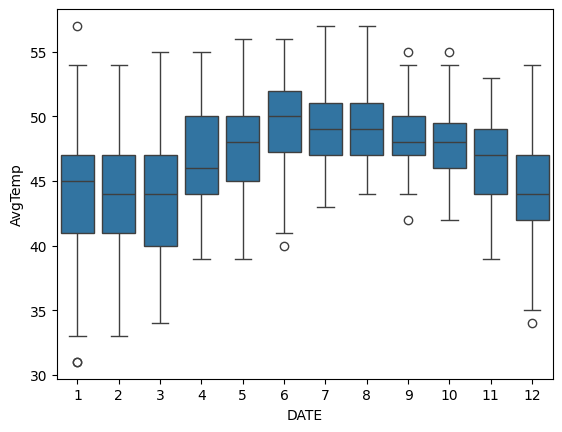

In [ ]:
sns.boxplot(x=weather.index.month, y=weather['AvgTemp'])

CLEARLY there is MONTHLY seasonality, the meadians and box shift up in middle of year

<Axes: ylabel='AvgTemp'>

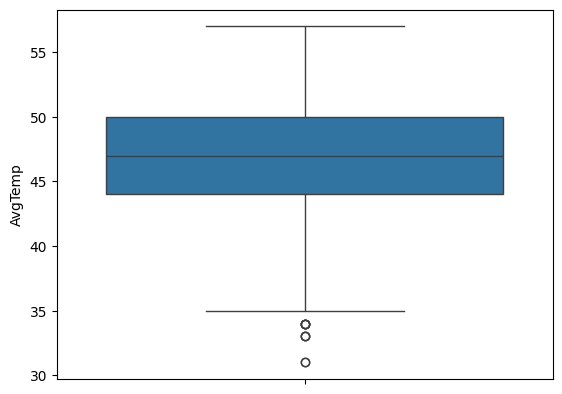

In [ ]:
sns.boxplot(weather['AvgTemp'])

<Axes: xlabel='DATE', ylabel='AvgTemp'>

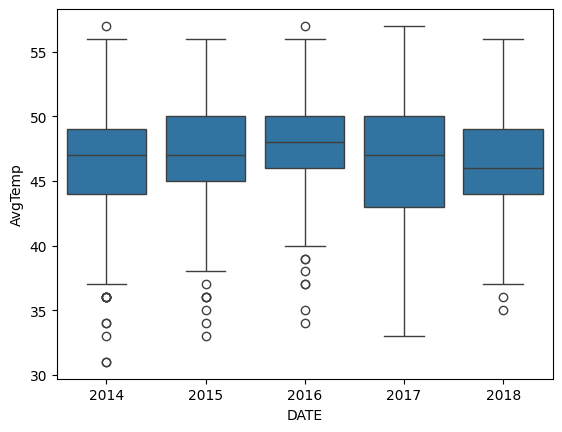

In [ ]:
sns.boxplot(x=weather.index.year, y=weather['AvgTemp'])

<Axes: xlabel='DATE', ylabel='AvgTemp'>

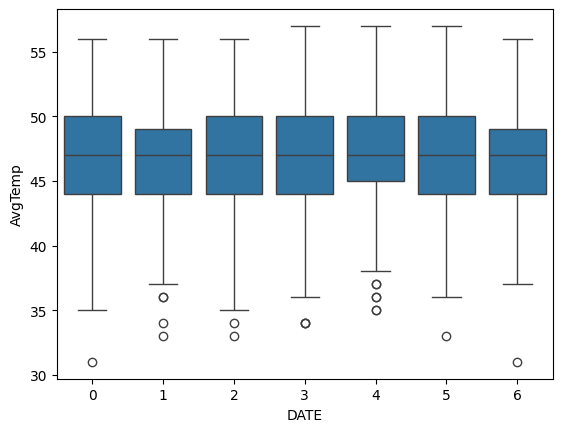

In [ ]:
sns.boxplot(x=weather.index.weekday, y=weather['AvgTemp'])

THERE IS NO WEEKLY SEASONALITY - medians are all almost same


In a boxplot:

* The **horizontal line inside the box** is the **median** (50th percentile) of the data for that group.
* The **top and bottom of the box** are the 75th percentile (Q3) and 25th percentile (Q1), respectively.
* The **whiskers** extend to show the range of most of the data (usually Q1–1.5*IQR to Q3+1.5*IQR).
* Any points beyond whiskers are **outliers**.

---

###### **How it shows seasonality**

* If you group by **month**, the median line moves up/down across months.

  * Higher median → hotter months.
  * Lower median → colder months.
* Repeating pattern of medians across months indicates **annual seasonality**.

So, yes — you check **seasonality by observing how the black median line shifts month to month**.

Here’s a **step-by-step way to check seasonality using boxplots in your temperature dataset**:

---

###### **1️⃣ Monthly Seasonality**

**What to look for:**

* **Median line** in each box: If medians change month to month (e.g., higher in summer, lower in winter), that’s **seasonality**.
* **Box size / whiskers**: Shows spread; bigger variations may indicate months with more extreme temperatures.
* If medians are roughly the same across months → little or no seasonality.

---

###### **2️⃣ Weekly Seasonality (Optional)**


**What to look for:**

* This is more relevant for sales, traffic, etc.
* If median temperatures differ by weekdays → unusual weekly pattern (rare for weather, but we can check).

---

###### **3️⃣ How to confirm seasonality**

1. **Median pattern repeats**: e.g., highest in June-July, lowest in December-January → annual seasonality.
2. **Boxplots form a pattern over time**: Peaks and troughs follow the expected seasonal cycle.
3. **Variation (spread) may also repeat**: Helps to see consistent seasonal behavior.

---

12. Answer - Both 1 and 2

13)  If the moving average component (q) in an ARIMA model = 1, Hence there will be the auto-correlation in the series with lag =1.
- FALSE
- TRUE

**MA (moving average) component (q)** is usually **decided by looking at the ACF (autocorrelation function)**, not PACF.

Here’s the rule of thumb for ARIMA:

---

###### **1️⃣ AR order (p) → PACF**

* Look at **Partial Autocorrelation Function (PACF)**.
* **Significant spikes in PACF** at lags → suggest AR terms.
* PACF **cuts off after lag p** for AR(p).

---

###### **2️⃣ MA order (q) → ACF**

* Look at **Autocorrelation Function (ACF)**.
* **Significant spikes in ACF** at lags → suggest MA terms.
* ACF **cuts off after lag q** for MA(q).

---

###### **Summary Table**

| Component | Use plot | How to decide                  |
| --------- | -------- | ------------------------------ |
| AR (p)    | PACF     | Last significant spike lag → p |
| MA (q)    | ACF      | Last significant spike lag → q |

---

✅ So, moving average (q) is **decided by ACF**, not PACF.



| Component | Use plot | Cutoff logic                            |
| --------- | -------- | --------------------------------------- |
| AR (p)    | PACF     | Last significant spike outside blue → p |
| MA (q)    | ACF      | Last significant spike outside blue → q |


Based on Perplexity research on ARIMA models and moving average processes, the answer is:

**TRUE**

###### Explanation:

When the moving average component (q) in an ARIMA model equals 1, creating an MA(1) process, there **will** be autocorrelation in the series at lag 1.[1][2][3][4][5]

###### Mathematical Proof:

For an MA(1) process: $X_t = w_t + \theta w_{t-1}$

The **autocorrelation function** is:
- $\rho(0) = 1$ (always)
- $\rho(1) = \frac{\theta}{1 + \theta^2}$ (non-zero for $\theta \neq 0$)
- $\rho(k) = 0$ for all $k > 1$[2][3][4][1]

###### Key Properties from Research:

1. **"For an MA(1), the autocovariance function truncates (i.e., it is zero) after lag 1"** - This means autocorrelation exists at lag 1 but not beyond.[1]

2. **"A sample ACF with significant autocorrelation only at lag 1 is an indicator of a potential MA(1) model"** - Confirming lag 1 autocorrelation is the defining characteristic.[3]

3. **"The autocorrelation function (ACF) of an MA(q) process is zero at lag q + 1 and greater"** - For MA(1), autocorrelation exists up to lag 1.[5]

### Research Evidence:

Multiple sources confirm that MA(1) processes exhibit:
- **Significant autocorrelation at lag 1**: $\rho(1) = \frac{\theta}{1 + \theta^2}$[4][2][3][1]
- **Zero autocorrelation beyond lag 1**: $\rho(k) = 0$ for $k > 1$ [2][3][4][1]
- **This pattern is diagnostic** for identifying MA(1) processes[6][7][3]

**Answer: TRUE**

The statement is correct - when q=1 in an ARIMA model, there will indeed be autocorrelation in the series at lag 1, which is the defining characteristic of MA(1) processes.[3][4][5][1][2]

[1](https://mcs.utm.utoronto.ca/~nosedal/sta457/ma1-and-ma2.pdf)
[2](https://real-statistics.com/time-series-analysis/moving-average-processes/ma-process-basic-concepts/)
[3](https://www.y1zhou.com/series/time-series/2-arma/time-series-moving-average-model/)
[4](https://online.stat.psu.edu/stat510/Lesson02.html)
[5](https://en.wikipedia.org/wiki/Moving-average_model)
[6](https://www.kaggle.com/code/iamleonie/time-series-interpreting-acf-and-pacf)
[7](https://www.quantstart.com/articles/Autoregressive-Moving-Average-ARMA-p-q-Models-for-Time-Series-Analysis-Part-2/)
[8](https://blog.quantinsti.com/autocorrelation-autocovariance/)
[9](https://people.duke.edu/~rnau/411arim.htm)
[10](https://www.scribd.com/document/385288936/Moving-Average-Model)
[11](https://www.geeksforgeeks.org/machine-learning/autocorrelation/)
[12](https://www.ritchievink.com/blog/2018/09/26/algorithm-breakdown-ar-ma-and-arima-models/)
[13](https://online.stat.psu.edu/stat462/node/188/)
[14](https://en.wikipedia.org/wiki/Autoregressive_integrated_moving_average)
[15](https://home.iitk.ac.in/~shalab/econometrics/Chapter9-Econometrics-Autocorrelation.pdf)
[16](https://statisticsbyjim.com/time-series/autocorrelation-partial-autocorrelation/)
[17](https://www.geeksforgeeks.org/machine-learning/understanding-the-moving-average-ma-in-time-series-data/)

Even if p=1, the auto correlation at lag=1 is true

The PACF has a very large spike at lag 1 and no other significant spikes, indicating that an AR(1) model should be used

Just like MA(1), when p=1 in an ARIMA model (AR(1) process), there will indeed be autocorrelation in the series at lag 1, which is the fundamental characteristic of AR(1) processes.

12. Answer - True

14) What is the expectation of the dependent variable for a Moving Average Model?
- All of the Above
- Constant
- Variable
- None of the Above

In this context, **“expectation” = statistical mean** of the dependent variable.

* In an MA(q) model, the series fluctuates because of the past errors $\epsilon_t$, but the **long-term average** (expected value) is the constant $\mu$.

So **expectation = mean = μ**.


Expectation of X, E(X) = ΣxP(x) or integration of x.f(x)

Based on Perplexity's research on Moving Average (MA) models and their mathematical properties, the answer is:

**Constant**

###### Explanation:

The expectation (mean) of the dependent variable in a Moving Average model is **constant**.[1][2][3][4][5][6]

###### Mathematical Proof:

For a general MA(q) model:
$X_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + \theta_2\varepsilon_{t-2} + ... + \theta_q\varepsilon_{t-q}$


Taking the expectation:
$E[X_t] = E[\mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + ... + \theta_q\varepsilon_{t-q}]$

  - $E[μ] = μ$ because μ is a constant parameter, not a random variable.

Since $E[\varepsilon_t] = 0$ for all white noise error terms:

$E[X_t] = \mu + 0 + 0 + ... + 0 = \mu$

###### Key Properties from Research:

1. **"The mean of the series, μ, is the constant term in the MA model"** - This shows μ is a constant parameter.[2][4][5]

2. **"MA models are stationary by definition... with constant mean"** - Stationarity requires constant mean over time.[4][5][1]

3. **"E[X_t] = 0 (when μ=0) for all t, showing the mean is time-invariant"** - The expectation doesn't depend on time t.[5]

4. **"One key requirement of the MA(q) model is that it needs the data to be stationary. This means it has a constant variance and mean through time"**[1]

###### Research Evidence:

Multiple sources confirm that MA models have constant expectations:
- **Wikipedia**: "μ is the mean of the series" in the MA model definition[2]
- **Statistical Learning Notes**: "E[X_t] = 0" (constant for all t)[5]
- **Towards Data Science**: MA models require "constant mean through time"[1]
- **University lectures**: Show E[X_t] = μ (constant) for MA processes[3][6]

**Answer: Constant**

The expectation of the dependent variable in a Moving Average model is always constant (μ), which is one of the fundamental properties that makes MA models stationary.[4][2][5][1]

[1](https://towardsdatascience.com/how-to-forecast-with-moving-average-models-6f3c9cbba60d/)
[2](https://en.wikipedia.org/wiki/Moving-average_model)
[3](https://www.bauer.uh.edu/rsusmel/phd/ec2-3.pdf)
[4](https://fiveable.me/forecasting/unit-5/moving-average-ma-models/study-guide/raHNNxVCDNkp1afN)
[5](https://dragonwarrior15.github.io/statistical-learning-notes/notes/time_series/chapters/arima/ma.html)
[6](https://mcs.utm.utoronto.ca/~nosedal/sta457/ma1-and-ma2.pdf)
[7](https://bookdown.org/josephs_david11/tsReview/expected-values-variance-etc-.html)
[8](https://www.statlect.com/fundamentals-of-probability/expected-value-properties)
[9](https://www.geeksforgeeks.org/machine-learning/understanding-the-moving-average-ma-in-time-series-data/)
[10](https://www.ctanujit.org/uploads/2/5/3/9/25393293/time_series_analysis_sd1final.pdf)
[11](https://www.geo.fu-berlin.de/en/v/soga-r/Advances-statistics/Time-series-analysis/Basic-properties-of-time-series/index.html)
[12](https://www.investopedia.com/terms/m/movingaverage.asp)
[13](https://otexts.com/fpp2/MA.html)
[14](https://analystprep.com/study-notes/frm/part-1/quantitative-analysis/modeling-cycles-ma-ar-and-arma-models/)

In the context of a **Moving Average (MA) model**, $\theta_t$ (often written $\theta_1, \theta_2, \dots, \theta_q$) are the **coefficients of past errors**. Let me explain clearly:

---

###### **MA(q) model**

$
X_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q}
$

Where:

| -- Symbol --                     | Meaning                                                             |
| --------------------------- | ------------------------------------------------------------------- |
| $X_t$                       | Value of the series at time t (dependent variable)                  |
| $\mu$                       | Mean (expectation) of the series                                    |
| $\epsilon_t$                | White noise at time t (random error, mean 0)                        |
| $\theta_1, \dots, \theta_q$ | MA coefficients — how much **past errors** affect the current value |
| q                           | Order of the MA process — number of past errors included            |

---

###### **Interpretation**

* $\theta_1$ → how much the previous period’s error $\epsilon_{t-1}$ affects $X_t$.
* $\theta_2$ → how much two periods ago’s error affects $X_t$, etc.
* These are **weights** applied to past shocks.

---

✅ So, $\theta_t$ or $\theta_1, \dots, \theta_q$ are **parameters that control the influence of past errors in a moving average model**.


There are q number of MA coeff. we can see in `model.params`. those are teta_1 to teat_q

14. Answer - Constant

15) Which of the following statements is True?
1. If there is no decay in the ACF values for any number of lags time series is Stationary
2. The rate of decay will determine the value of the coefficient terms.
3. In a Time Series coefficient for the residual error terms can be negative
- 1 only
- All of the Above
- 2 and 3 only
- 1 and 3 only

The statement on GeeksforGeeks is incorrect. In fact:

- Decaying ACF (autocorrelations that diminish toward zero as lag increases) is a hallmark of a stationary series (e.g., AR processes)

- Persistent ACF (little to no decay) indicates non-stationarity (such as a unit-root or strong trend)

So decay in the ACF implies stationarity rather than trend or seasonality.

The correct answer is:

**2 and 3 only** ✅

---

###### **Explanation**

1. **“If there is no decay in the ACF values … series is stationary”** → ❌

   * Actually, **stationary series** has ACF **decaying quickly** (exponentially or cutoff).
   * If ACF does **not decay**, it usually indicates **non-stationarity**.

2. **“The rate of decay will determine the value of the coefficient terms”** → ✅

   * The **speed at which ACF/PACF decays** helps identify **AR/MA coefficients**.
   * Slow decay → higher-order AR terms; cutoff → MA terms.

3. **“In a Time Series coefficient for the residual error terms can be negative”** → ✅

residual error here is how past data affects ACF which is not direct correlation to t-lag data which we calculate in PACF only

   * MA coefficients $\theta_i$ can be **positive or negative**, depending on how past shocks affect the series.

---

So statements **2 and 3** are true, while **1 is false**.


15. Answer - 2 and 3 only

**15. The given correct answer as per answer key - All of the Above**

16) How many days TCS did movement of more than 150 points i.e difference between High and Low? (Use stocks.csv for this question)
- 8
- 13
- 5
- 20

It seems this data is historic stock price of TCS

In [ ]:
stocks = pd.read_csv('/content/stocks.csv')

In [ ]:
stocks

,Date,Open,High,Low,Close
0,9/14/2018,2044.000000,2071.550049,2018.150024,2065.399902
1,9/17/2018,2070.000000,2077.800049,2054.550049,2074.149902
2,9/18/2018,2073.000000,2078.800049,2057.600098,2070.750000
3,9/19/2018,2071.899902,2089.000000,2066.850098,2077.899902
4,9/21/2018,2077.000000,2121.000000,2050.149902,2103.149902
...,...,...,...,...,...
1230,9/7/2023,3430.800049,3460.000000,3422.300049,3455.250000
1231,9/8/2023,3455.250000,3465.000000,3435.050049,3441.899902
1232,9/11/2023,3462.000000,3485.699951,3445.000000,3480.649902
1233,9/12/2023,3492.000000,3589.899902,3483.000000,3580.800049


In [ ]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1235 non-null   object 
 1   Open    1235 non-null   float64
 2   High    1235 non-null   float64
 3   Low     1235 non-null   float64
 4   Close   1235 non-null   float64
dtypes: float64(4), object(1)
memory usage: 48.4+ KB


In [ ]:
stocks.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


In [ ]:
stocks.duplicated().sum()

0

In [ ]:
stocks['Movement'] = stocks['High'] - stocks['Low']

In [ ]:
stocks['Movement']

,Movement
0,53.400025
1,23.250000
2,21.199951
3,22.149902
4,70.850098
...,...
1230,37.699951
1231,29.949951
1232,40.699951
1233,106.899902


In [ ]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1235 non-null   object 
 1   Open      1235 non-null   float64
 2   High      1235 non-null   float64
 3   Low       1235 non-null   float64
 4   Close     1235 non-null   float64
 5   Movement  1235 non-null   float64
dtypes: float64(5), object(1)
memory usage: 58.0+ KB


In [ ]:
(stocks['Movement']>150).sum()

8

16. Answer - 8

17) Choose the first lag value between 0 to 30 where the ACF drops to zero for the column Low? (Use stocks.csv for this question)
- No lag reached zero value
- 20
- 3
- 12

In [ ]:
type(stocks['Date'][0])

str

In [ ]:
# Convert Date to datetime
stocks['Date'] = pd.to_datetime(stocks['Date'])

In [ ]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1235 non-null   datetime64[ns]
 1   Open      1235 non-null   float64       
 2   High      1235 non-null   float64       
 3   Low       1235 non-null   float64       
 4   Close     1235 non-null   float64       
 5   Movement  1235 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 58.0 KB


In [ ]:
expected_dates_stocks = pd.date_range(start=stocks['Date'].min(), end=stocks['Date'].max(), freq='B')  # 'B' = business day

In [ ]:
expected_dates_stocks.difference(stocks['Date']) # these are just market holidays

DatetimeIndex(['2018-09-20', '2018-10-02', '2018-10-18', '2018-11-08',
               '2018-11-23', '2018-12-25', '2019-02-13', '2019-03-04',
               '2019-03-21', '2019-03-29', '2019-04-17', '2019-04-19',
               '2019-04-29', '2019-05-01', '2019-06-05', '2019-08-12',
               '2019-08-15', '2019-09-02', '2019-09-10', '2019-10-02',
               '2019-10-08', '2019-10-21', '2019-10-28', '2019-11-12',
               '2019-12-25', '2020-02-21', '2020-03-10', '2020-04-02',
               '2020-04-06', '2020-04-10', '2020-04-14', '2020-05-01',
               '2020-05-25', '2020-10-02', '2020-11-16', '2020-11-30',
               '2020-12-25', '2021-01-26', '2021-03-11', '2021-03-29',
               '2021-04-02', '2021-04-14', '2021-04-21', '2021-05-13',
               '2021-07-21', '2021-08-19', '2021-09-10', '2021-10-15',
               '2021-11-05', '2021-11-19', '2022-01-26', '2022-03-01',
               '2022-03-18', '2022-04-14', '2022-04-15', '2022-05-03',
      

In [ ]:
# no need to fill anything
# we can directly make it as index

In [ ]:
(stocks['Date'] == stocks['Date'].sort_values())

,Date
0,True
1,True
2,True
3,True
4,True
...,...
1230,True
1231,True
1232,True
1233,True


In [ ]:
(stocks['Date'] == stocks['Date'].sort_values()).all()

True

In [ ]:
stocks.set_index('Date', inplace=True)

In [ ]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1235 entries, 2018-09-14 to 2023-09-13
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Open      1235 non-null   float64
 1   High      1235 non-null   float64
 2   Low       1235 non-null   float64
 3   Close     1235 non-null   float64
 4   Movement  1235 non-null   float64
dtypes: float64(5)
memory usage: 57.9 KB


In [ ]:
stocks

,Open,High,Low,Close,Movement
Date,,,,,
2018-09-14,2044.000000,2071.550049,2018.150024,2065.399902,53.400025
2018-09-17,2070.000000,2077.800049,2054.550049,2074.149902,23.250000
2018-09-18,2073.000000,2078.800049,2057.600098,2070.750000,21.199951
2018-09-19,2071.899902,2089.000000,2066.850098,2077.899902,22.149902
2018-09-21,2077.000000,2121.000000,2050.149902,2103.149902,70.850098
...,...,...,...,...,...
2023-09-07,3430.800049,3460.000000,3422.300049,3455.250000,37.699951
2023-09-08,3455.250000,3465.000000,3435.050049,3441.899902,29.949951
2023-09-11,3462.000000,3485.699951,3445.000000,3480.649902,40.699951


17) Choose the first lag value between 0 to 30 where the ACF drops to zero for the column Low? (Use stocks.csv for this question)
- No lag reached zero value
- 20
- 3
- 12

In [ ]:
acf(stocks['Low'], nlags=30)

array([1.        , 0.99703359, 0.99389506, 0.99101476, 0.98824728,
       0.98535912, 0.98249193, 0.97956765, 0.97693207, 0.97442782,
       0.97185334, 0.96931581, 0.96683376, 0.96420702, 0.96151671,
       0.95890808, 0.95633159, 0.95361413, 0.95074123, 0.94800636,
       0.94515266, 0.94208683, 0.93899123, 0.93577284, 0.93258769,
       0.92947967, 0.92650584, 0.9236952 , 0.920948  , 0.9181747 ,
       0.91554471])

In [ ]:
len(acf(stocks['Low'], nlags=30))

31

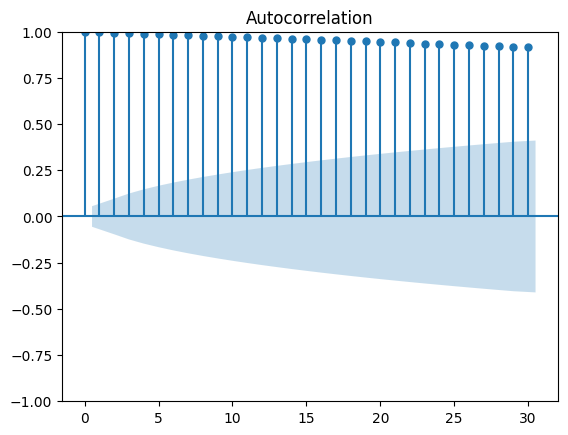

In [ ]:
plot_acf(stocks['Low'], lags=30)
plt.show()

In [ ]:
acf_vals_low = acf(stocks['Low'], nlags=30)

In [ ]:
acf_vals_low.ndim

1

In [ ]:
np.where(acf_vals_low <= 0) # tuple, row index and col index. we take only row index

(array([], dtype=int64),)

In [ ]:
np.where(acf_vals_low <= 0)[0] # indexes that satisfies condition

array([], dtype=int64)

In [ ]:
# np.where(acf_vals_low <= 0)[0][0]

# we take 1st index that satisfies condition

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
lags_low = np.arange(len(acf_vals_low))
first_zero_lag_low = lags_low[np.where(acf_vals_low <= 0)[0][0]] if any(acf_vals_low <= 0) else None
print(first_zero_lag_low)

None


In [ ]:
first_zero_lag_low = next((i for i, val in enumerate(acf_vals_low) if val <= 0), None)

# Print ACF values and first zero lag
for i, val in enumerate(acf_vals_low):
  print(f"Lag {i}: {val:.4f}")
print("\nFirst lag where ACF <= 0:", first_zero_lag_low if first_zero_lag_low is not None else "No lag reached zero value")

Lag 0: 1.0000
Lag 1: 0.9970
Lag 2: 0.9939
Lag 3: 0.9910
Lag 4: 0.9882
Lag 5: 0.9854
Lag 6: 0.9825
Lag 7: 0.9796
Lag 8: 0.9769
Lag 9: 0.9744
Lag 10: 0.9719
Lag 11: 0.9693
Lag 12: 0.9668
Lag 13: 0.9642
Lag 14: 0.9615
Lag 15: 0.9589
Lag 16: 0.9563
Lag 17: 0.9536
Lag 18: 0.9507
Lag 19: 0.9480
Lag 20: 0.9452
Lag 21: 0.9421
Lag 22: 0.9390
Lag 23: 0.9358
Lag 24: 0.9326
Lag 25: 0.9295
Lag 26: 0.9265
Lag 27: 0.9237
Lag 28: 0.9209
Lag 29: 0.9182
Lag 30: 0.9155

First lag where ACF <= 0: No lag reached zero value


17. Answer - No lag reached zero value

18) Choose the correct lag value between 0 to 30 using PACF for the column Open which indicates the order of AutoRegressive components in the ARIMA model? (Use stocks.csv for this question)
- 11
- 23
- 4
- 0

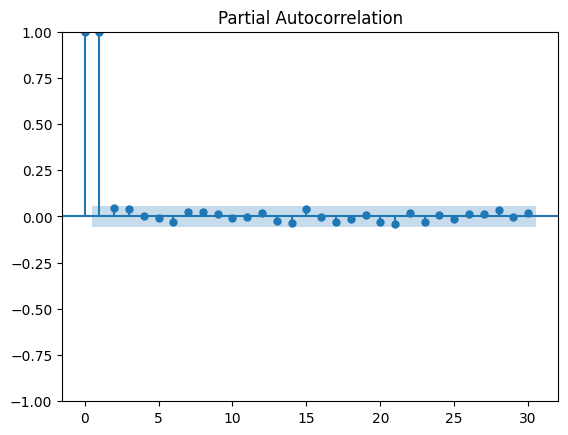

In [ ]:
plot_pacf(stocks['Open'], lags=30)
plt.show()

**last lag outside confidence interval is 3**

In [ ]:
pacf_vals_open = pacf(stocks['Open'], nlags=30)

In [ ]:
conf_int_open = 1.96/np.sqrt(len(stocks['Open']))

# find first lag (excluding lag 0) above confidence
ar_lag_open = next((i for i in range(1, len(pacf_vals_open)) if abs(pacf_vals_open[i]) > conf_int_open), 0)
print("Suggested AR order (p):", ar_lag_open)


Suggested AR order (p): 3


In [ ]:
pacf_vals_open

array([ 1.00000000e+00,  9.97523753e-01,  6.12766221e-02,  5.40856365e-02,
        7.99177989e-03, -1.32115365e-02, -3.65407770e-02,  3.08858797e-02,
        2.98343660e-02,  2.27637622e-02, -1.18121638e-02, -1.49503016e-03,
        2.78919415e-02, -3.22818748e-02, -4.45428111e-02,  5.28386476e-02,
       -4.62657769e-03, -4.02506391e-02, -1.65263465e-02,  1.31993837e-02,
       -4.37716537e-02, -5.64876352e-02,  2.70823705e-02, -3.68707933e-02,
        8.35433167e-03, -1.68340681e-02,  2.12667208e-02,  1.62525475e-02,
        4.52646441e-02,  8.53240215e-04,  2.77854173e-02])

In [ ]:
conf_int_open

0.055772818535998275

In [ ]:
pacf_vals_open < conf_int_open # inside confidence interval

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [ ]:
pacf_vals_open - conf_int_open

array([ 0.94422718,  0.94175093,  0.0055038 , -0.00168718, -0.04778104,
       -0.06898436, -0.0923136 , -0.02488694, -0.02593845, -0.03300906,
       -0.06758498, -0.05726785, -0.02788088, -0.08805469, -0.10031563,
       -0.00293417, -0.0603994 , -0.09602346, -0.07229917, -0.04257343,
       -0.09954447, -0.11226045, -0.02869045, -0.09264361, -0.04741849,
       -0.07260689, -0.0345061 , -0.03952027, -0.01050817, -0.05491958,
       -0.0279874 ])

In [ ]:
pacf_vals_open_1, conf_int_open_1 = pacf(stocks['Open'], nlags=30, alpha=0.05)

In [ ]:
conf_int_open_1

array([[ 1.00000000e+00,  1.00000000e+00],
       [ 9.41751960e-01,  1.05329555e+00],
       [ 5.50482843e-03,  1.17048416e-01],
       [-1.68615718e-03,  1.09857430e-01],
       [-4.77800138e-02,  6.37635736e-02],
       [-6.89833302e-02,  4.25602571e-02],
       [-9.23125707e-02,  1.92310167e-02],
       [-2.48859140e-02,  8.66576734e-02],
       [-2.59374277e-02,  8.56061597e-02],
       [-3.30080315e-02,  7.85355559e-02],
       [-6.75839575e-02,  4.39596299e-02],
       [-5.72668239e-02,  5.42767635e-02],
       [-2.78798522e-02,  8.36637352e-02],
       [-8.80536685e-02,  2.34899189e-02],
       [-1.00314605e-01,  1.12289826e-02],
       [-2.93314611e-03,  1.08610441e-01],
       [-6.03983714e-02,  5.11452160e-02],
       [-9.60224328e-02,  1.55211546e-02],
       [-7.22981402e-02,  3.92454472e-02],
       [-4.25724100e-02,  6.89711774e-02],
       [-9.95434474e-02,  1.20001400e-02],
       [-1.12259429e-01, -7.15841469e-04],
       [-2.86894232e-02,  8.28541642e-02],
       [-9.

In [ ]:
# Get all significant lags
significant_lags_open = [i for i in range(1, len(pacf_vals_open_1)) if pacf_vals_open_1[i] > conf_int_open_1[i][0] or pacf_vals_open_1[i] < conf_int_open_1[i][1]]

# AR order is the last significant lag
p = significant_lags_open[-1] if significant_lags_open else 0
print("Suggested AR order (p):", p)


Suggested AR order (p): 30


In [ ]:
significant_lags_open

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30]

From the picture plot, the closest one in options is 4

18. Answer - 4

19. What is the value of the last 20 days Simple Moving average for the column Low? (Use stocks.csv for this question)

- I have not take note of options from quiz. There were 4 options, 1 is 3396.17, others are 3000 to 3500 nearly but none is 3300 something other than the mentioned correct option

In [ ]:
rolling_mean_low=stocks['Low'].rolling(window=20).mean()

In [ ]:
rolling_mean_low

,Low
Date,
2018-09-14,NaN
2018-09-17,NaN
2018-09-18,NaN
2018-09-19,NaN
2018-09-21,NaN
...,...
2023-09-07,3385.277515
2023-09-08,3385.527515
2023-09-11,3387.077515


In [ ]:
rolling_mean_low.tail(20)

,Low
Date,
2023-08-17,3401.677515
2023-08-18,3397.700012
2023-08-21,3398.347510
2023-08-22,3397.995007
2023-08-23,3397.785010
2023-08-24,3397.440015
2023-08-25,3395.700012
2023-08-28,3397.155017
2023-08-29,3397.360022


In [ ]:
rolling_mean_low.tail(20).mean()

3393.4760150675

In [ ]:
rolling_mean_low[-1]

3396.16751715

In [ ]:
rolling_mean_center_low=stocks['Low'].rolling(window=20, center=True).mean()

In [ ]:
rolling_mean_center_low

,Low
Date,
2018-09-14,NaN
2018-09-17,NaN
2018-09-18,NaN
2018-09-19,NaN
2018-09-21,NaN
...,...
2023-09-07,NaN
2023-09-08,NaN
2023-09-11,NaN


In [ ]:
rolling_mean_center_low.head(21)

,Low
Date,
2018-09-14,NaN
2018-09-17,NaN
2018-09-18,NaN
2018-09-19,NaN
2018-09-21,NaN
2018-09-24,NaN
2018-09-25,NaN
2018-09-26,NaN
2018-09-27,NaN


In [ ]:
rolling_mean_center_low.tail(21)

,Low
Date,
2023-08-16,3397.360022
2023-08-17,3395.762524
2023-08-18,3392.265015
2023-08-21,3391.705017
2023-08-22,3390.145020
2023-08-23,3388.340015
2023-08-24,3385.415015
2023-08-25,3385.277515
2023-08-28,3385.527515


In [ ]:
rolling_mean_low.tail(20).mean()

3393.4760150675

In [ ]:
rolling_mean_low[-1]

3396.16751715

19. Answer - 3396.17

20. Choose the right options to improve the below model prediction where the red line is the actual value and the blue one is the predicted value? (Use stocks.csv)

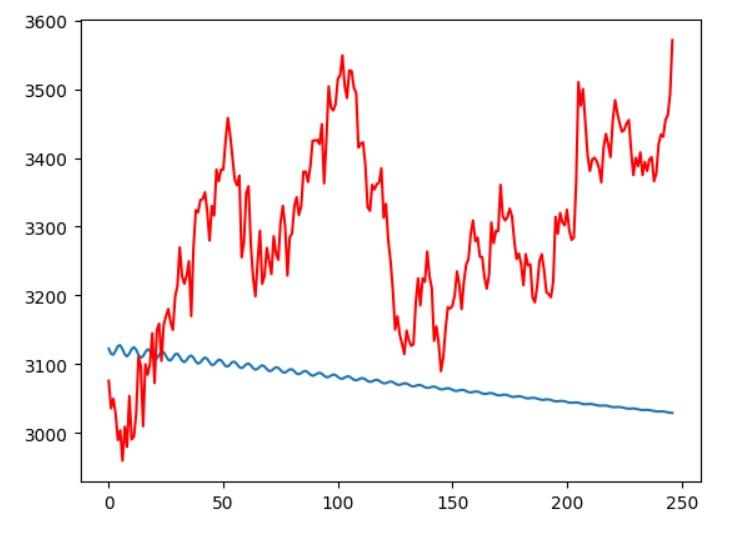

- All options are correct
- Data is not stationary.
- Our dataset is very small, it may not provide enough information for the model to learn meaningful patterns.
- Model is too simple to capture the underlying patterns.

All options are correct. The poor prediction performance can be attributed to multiple factors: the data is non-stationary, the dataset is small (limiting pattern learning), and the model is too simple to capture the complex underlying dynamics.

The red vs. blue plot shows a systematic divergence between actual and predicted values—here’s how each issue contributes:

1. Data Is Not Stationary  
   -  Non-stationary series have time-varying mean, variance, or autocorrelation (e.g., underlying trends, changing volatility). Models like simple moving averages or basic regressors assume stationarity and will misfit when those assumptions break. In the plot, the actual values exhibit trending behavior and volatility clustering that the flat, slowly drifting blue forecast cannot follow.

2. Dataset Is Very Small  
   -  With limited historical points, the model sees only a narrow window of patterns. It cannot learn longer-term cycles or rare regime shifts (sharp rises/falls). This paucity of examples forces the model to over-generalize, producing overly smooth forecasts that miss the true market swings.

3. Model Is Too Simple  
   -  A very simple model (e.g., a basic linear regressor or low-order ARIMA) cannot capture the complex interactions, nonlinearity, or regime changes present in stock data. The result is underfitting: forecasts that lag behind rapid up-moves or down-moves and fail to adapt to changing dynamics.

4. All Options Together  
   -  Non-stationarity demands differencing, detrending, or advanced features (e.g., volatility measures). Small data requires data augmentation or longer histories. Complexity in patterns calls for richer models (e.g., higher-order ARIMA, GARCH for volatility, or machine-learning models like random forests or LSTM networks). Addressing all these—making the series stationary, enlarging the dataset, and using a more powerful model—will jointly improve the forecasts, aligning the blue line more closely with the red.

The given picture (with the jagged red line and smoother blue prediction) is **likely non-stationary**, and the primary reason appears to be **trend and changing variance**.

- The red line (actual values) shows an **upward trend** in the later part, as well as long periods of rising and falling levels, which means the mean is not constant over time.
- There are also intervals with large spikes and occasional regime changes, suggesting that the **variance is changing** throughout the series, another violation of stationarity.
- Stationary series should have a roughly constant mean and variance throughout the entire time range.

Thus, while trend is a major contributing factor, non-constant variance and possibly other structural changes also make the data non-stationary in this plot. Removing trend and stabilizing variance (for example, by differencing or transformation) would be necessary to make this series stationary.

20. Answer - All options are correct

**Marks obtained - 17/20**